In [1]:
# Cell 1: Setup — JackSparrow v15
# GitHub: https://github.com/energyforreal/JackSparrow
#
# v15 Optimisations (over v14):
#  [v15-1] CONFIDENCE_PERCENTILE raised 85 → 90 (top 10% signals only)
#  [v15-2] EDGE_FLOOR raised 0.12 → 0.15 (higher minimum edge quality)
#  [v15-3] ATR_TRAILING_MULT = 1.5  — ATR-based trailing stop replaces fixed %
#  [v15-4] MIN_HOLD_BARS = 5        — prevents premature noise exits
#  [v15-5] EDGE_DECAY_THRESHOLD     — exits when edge fades below 0.05
#  [v15-6] VOLATILITY_FILTER_PCT    — skips trades in dead/choppy markets
#
# v14 Fixes retained:
#  Strict 80/20 temporal holdout | per-fold sanitise+corr-prune | train-derived
#  median imputation | ffill(limit=5) only | frozen feature order | tighter KS
#  drift alpha | position-scaled cost model | SELL/BUY weight boost |
#  full pipeline pickle

import subprocess, sys

pkgs = [
    "xgboost==2.0.2", "scikit-learn", "pandas", "numpy",
    "requests", "joblib", "matplotlib", "seaborn", "shap",
    "tqdm", "numba", "imbalanced-learn", "scipy",
]
try:
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet"] + pkgs, check=True)
except subprocess.CalledProcessError as e:
    print(f"[WARN] pip install partial failure: {e}")

import requests, time, json, joblib, shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import ks_2samp
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.calibration import CalibratedClassifierCV
from xgboost import XGBClassifier

try:
    from google.colab import drive
    drive.mount('/content/drive')
except Exception:
    print('Google Drive mount skipped (not in Colab)')

BASE_URL   = "https://api.india.delta.exchange/v2"
SYMBOL     = "BTCUSD"
PRODUCT_ID = 27
TIMEFRAMES = ["5m", "15m"]

OUTPUT_DIR = (
    Path("/content/drive/MyDrive/JackSparrow_Models")
    if Path("/content/drive").exists()
    else Path("./models")
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONTRACT_VALUE_BTC = 0.001
TAKER_FEE          = 0.0005
SLIPPAGE_BPS       = 5

TP_LONG_PCT  = 0.006
SL_LONG_PCT  = 0.004
TP_SHORT_PCT = 0.004
SL_SHORT_PCT = 0.006

RANDOM_STATE = 42

# ── Signal quality thresholds [v15-1, v15-2] ─────────────────────────────────
CONFIDENCE_PERCENTILE = 90          # [v15-1] was 85; trades only top 10% by |edge|
EDGE_FLOOR            = 0.15        # [v15-2] was 0.12; hard minimum edge to trade

# ── Execution optimisations [v15-3..6] ───────────────────────────────────────
ATR_TRAILING_MULT      = 1.5        # [v15-3] ATR multiplier for trailing stop
MIN_HOLD_BARS          = 5          # [v15-4] minimum bars before allowing exit
EDGE_DECAY_THRESHOLD   = 0.05       # [v15-5] close long if edge drops below this
VOLATILITY_FILTER_PCT  = 0.002      # [v15-6] skip trade if atr_pct < threshold

# ── Trade management ─────────────────────────────────────────────────────────
MIN_EDGE_COST_RATIO   = 2.0
MIN_GAP_CANDLES       = 3
TF_MAX_TRADES_DAY     = {"5m": 8, "15m": 4}

# ── Feature selection ────────────────────────────────────────────────────────
TOP_N_FEATURES   = 20               # features kept after importance selection
CORR_THRESHOLD   = 0.95             # correlation pruning threshold
HOLDOUT_FRAC     = 0.20             # 20% tail reserved as untouched holdout

print("Setup complete (v15)")
print(f"   Active timeframes       : {TIMEFRAMES}")
print(f"   Output directory        : {OUTPUT_DIR}")
print(f"   TP long / short         : {TP_LONG_PCT:.1%} / {TP_SHORT_PCT:.1%}")
print(f"   SL long / short         : {SL_LONG_PCT:.1%} / {SL_SHORT_PCT:.1%}")
print(f"   Signal threshold        : top {100-CONFIDENCE_PERCENTILE}% by |edge|, floor={EDGE_FLOOR}")
print(f"   ATR trailing multiplier : {ATR_TRAILING_MULT}x")
print(f"   Min hold bars           : {MIN_HOLD_BARS}")
print(f"   Edge decay threshold    : {EDGE_DECAY_THRESHOLD}")
print(f"   Volatility filter       : atr_pct >= {VOLATILITY_FILTER_PCT}")
print(f"   Top-N features          : {TOP_N_FEATURES}")


Mounted at /content/drive
Setup complete (v15)
   Active timeframes       : ['5m', '15m']
   Output directory        : /content/drive/MyDrive/JackSparrow_Models
   TP long / short         : 0.6% / 0.4%
   SL long / short         : 0.4% / 0.6%
   Signal threshold        : top 10% by |edge|, floor=0.15
   ATR trailing multiplier : 1.5x
   Min hold bars           : 5
   Edge decay threshold    : 0.05
   Volatility filter       : atr_pct >= 0.002
   Top-N features          : 20


In [2]:
# Cell 2: Fetch historical OHLCV -- v10 CRITICAL FIX
#
# ROOT CAUSE OF THE 2100-ROW BUG:
# Delta Exchange /v2/history/candles returns candles DESCENDING (newest first).
# v9 loop used: last_ts = batch[-1]["time"]  <- OLDEST candle
#               current_start = last_ts + resolution_s
# Result: window barely advanced -> same tiny window re-fetched -> 197900 duplicates
#         -> only 2100 unique rows survived deduplication.
#
# FIX [v10-1/v10-2]:
#   Walk BACKWARD from end_ts toward start_ts.
#   After each batch: current_end = batch[-1]["time"] - resolution_s
#   (batch[-1] is the OLDEST candle in a descending batch)
#   Reverse the collected list at the end to produce ascending order.
#
# FIX [v10-3]: Hard progress guard -- force window jump if stuck.
# FIX [v10-4]: Debug logging on every request.

import requests
import time
import pandas as pd
import numpy as np

try:
    from tqdm.auto import tqdm as _tqdm
    HAS_TQDM = True
except ImportError:
    HAS_TQDM = False

MAX_CANDLES_PER_REQ = 2000
REQUEST_DELAY       = 0.12
MAX_RETRIES         = 3
FFILL_GAP_LIMIT     = 3
TF_TO_SECONDS       = {"5m": 300, "15m": 900}
TF_TARGET_CANDLES   = {"5m": 200_000, "15m": 100_000}
GAP_BUFFER_RATIO    = 1.10
OHLCV_COLS          = ["open", "high", "low", "close", "volume"]
HEADERS             = {"User-Agent": "python-rest-client/1.0", "Accept": "application/json"}


def fetch_candles_delta_v10(symbol, resolution, target_candles):
    all_candles  = []
    resolution_s = TF_TO_SECONDS[resolution]
    now_ts       = int(time.time())

    # Never include live/partial candle
    current_end = now_ts - resolution_s

    # How far back we need to look (with buffer)
    buffer_candles = int(target_candles * GAP_BUFFER_RATIO)
    hard_start_ts  = current_end - (buffer_candles * resolution_s)
    window_size    = MAX_CANDLES_PER_REQ * resolution_s
    _req_count     = 0

    pbar = (
        _tqdm(total=target_candles, desc=f"{symbol} {resolution}",
              unit="candle", dynamic_ncols=True, miniters=500)
        if HAS_TQDM else None
    )
    _prev_pbar_n = 0

    def _update_bar(done=False):
        nonlocal _prev_pbar_n
        if pbar is None:
            return
        new_n = min(len(all_candles), target_candles)
        delta = new_n - _prev_pbar_n
        if delta > 0:
            pbar.update(delta)
            _prev_pbar_n = new_n
        cur_date = pd.to_datetime(current_end, unit="s").strftime("%Y-%m-%d")
        pbar.set_postfix_str(f"window_end={cur_date}  reqs={_req_count}", refresh=False)
        if done:
            pbar.n = target_candles
            pbar.set_postfix_str(f"done  reqs={_req_count}", refresh=True)
            pbar.close()

    # [v10-2] Walk BACKWARD: current_end decreases each iteration
    while len(all_candles) < target_candles and current_end > hard_start_ts:

        current_start = max(current_end - window_size, hard_start_ts)
        params = {
            "symbol":     symbol,
            "resolution": resolution,
            "start":      int(current_start),
            "end":        int(current_end),
        }

        prev_len = len(all_candles)  # [v10-3] progress baseline

        for retry in range(MAX_RETRIES):
            try:
                r = requests.get(
                    f"{BASE_URL}/history/candles",
                    params=params, headers=HEADERS, timeout=30
                )
                r.raise_for_status()
                data = r.json()

                if not data.get("success"):
                    raise ValueError(f"API error: {data.get('error', data)}")

                batch = data.get("result", [])
                _req_count += 1

                # [v10-4] Debug log every request
                if batch:
                    newest = pd.to_datetime(batch[0]["time"],  unit="s").strftime("%Y-%m-%d %H:%M")
                    oldest = pd.to_datetime(batch[-1]["time"], unit="s").strftime("%Y-%m-%d %H:%M")
                    print(f"  [{resolution}] req#{_req_count:04d}: {len(batch):4d} candles"
                          f" | {oldest} -> {newest}"
                          f" | total: {len(all_candles) + len(batch):,}")
                else:
                    s_str = pd.to_datetime(current_start, unit="s").strftime("%Y-%m-%d")
                    e_str = pd.to_datetime(current_end,   unit="s").strftime("%Y-%m-%d")
                    print(f"  [{resolution}] req#{_req_count:04d}: EMPTY | window {s_str} -> {e_str}")

                if not batch:
                    # Empty window -- jump further back
                    current_end = current_start - resolution_s
                    _update_bar()
                    break

                all_candles.extend(batch)

                # [v10-1/v10-2] CRITICAL: step back past OLDEST candle in this batch
                # batch is descending -> batch[-1] is oldest
                current_end = batch[-1]["time"] - resolution_s

                _update_bar()

                if len(all_candles) >= target_candles:
                    _update_bar(done=True)
                    return all_candles[:target_candles]

                time.sleep(REQUEST_DELAY)
                break

            except Exception as e:
                if retry == MAX_RETRIES - 1:
                    msg = f"  Error after {MAX_RETRIES} retries: {e}"
                    print(msg)
                    if pbar:
                        pbar.close()
                    return all_candles[:target_candles]
                time.sleep(2 ** retry)

        # [v10-3] Hard progress guard
        if len(all_candles) == prev_len:
            print(f"  [{resolution}] No progress -- forcing window jump")
            current_end -= window_size

    if pbar:
        _update_bar(done=True)

    return all_candles[:target_candles]


def validate_and_clean(df, resolution):
    resolution_s = TF_TO_SECONDS[resolution]
    report = {}

    df = df.sort_values("time").reset_index(drop=True)

    for col in OHLCV_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype("float64")

    n_dups = df.duplicated(subset=["time"]).sum()
    if n_dups > 0:
        print(f"  [{resolution}] {n_dups} duplicate timestamps removed.")
    df = df.drop_duplicates(subset=["time"]).reset_index(drop=True)
    report["duplicates_removed"] = int(n_dups)

    df["_delta"] = df["time"].diff()
    gap_mask     = (df["_delta"] != resolution_s) & df["_delta"].notna()
    n_raw_gaps   = int(gap_mask.sum())

    df["datetime"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df = df.set_index("datetime")
    freq_alias = f"{resolution_s}s"
    full_idx   = pd.date_range(start=df.index.min(), end=df.index.max(), freq=freq_alias, tz="UTC")
    df           = df.reindex(full_idx)
    missing_mask = df["time"].isna()
    n_missing    = int(missing_mask.sum())

    run_id   = (missing_mask != missing_mask.shift()).cumsum()
    run_lens = missing_mask.groupby(run_id).transform("sum")
    large_gap = missing_mask & (run_lens > FFILL_GAP_LIMIT)

    df = df.ffill()
    df.loc[large_gap, OHLCV_COLS] = np.nan

    df["time"]     = (df.index.astype("int64") // 1_000_000_000).astype("int64")
    df["datetime"] = df.index
    df = df.reset_index(drop=True).drop(columns=["_delta"], errors="ignore")

    now_ts = int(time.time())
    df = df[df["time"] <= now_ts - resolution_s].reset_index(drop=True)

    report.update({
        "raw_gaps":      n_raw_gaps,
        "missing_bars":  n_missing,
        "final_candles": len(df),
        "date_start":    str(df["datetime"].min().date()) if len(df) else "N/A",
        "date_end":      str(df["datetime"].max().date()) if len(df) else "N/A",
    })
    return df, report


def print_quality_report(tf, report, target):
    n      = report["final_candles"]
    pct    = n / target * 100 if target else 0
    status = "OK" if pct >= 90 else "WARN"
    print(f"  [{status}] {tf}: {n:,} / {target:,} ({pct:.1f}%) | "
          f"{report['date_start']} -> {report['date_end']} | "
          f"dups removed: {report['duplicates_removed']}")


# Execution
raw_data = {}
for tf in TIMEFRAMES:
    target = TF_TARGET_CANDLES[tf]
    print(f"\n{'='*60}")
    print(f"Fetching {tf} | target={target:,} | buffer={int(target*GAP_BUFFER_RATIO):,}")

    candles = fetch_candles_delta_v10(SYMBOL, tf, target)

    if not candles:
        print(f"  {tf}: no candles returned -- skipping.")
        continue

    # API returns descending -- reverse to get ascending order
    candles = list(reversed(candles))

    df = pd.DataFrame(candles)
    df["datetime"] = pd.to_datetime(df["time"], unit="s", utc=True)
    df, report = validate_and_clean(df, tf)
    raw_data[tf] = df
    print_quality_report(tf, report, target)

print("\nAll fetches complete.")



Fetching 5m | target=200,000 | buffer=220,000


BTCUSD 5m:   0%|          | 0/200000 [00:00<?, ?candle/s]

  [5m] req#0001: 2000 candles | 2026-03-29 20:25 -> 2026-04-05 19:00 | total: 2,000
  [5m] req#0002: 2001 candles | 2026-03-22 21:40 -> 2026-03-29 20:20 | total: 4,001
  [5m] req#0003: 2001 candles | 2026-03-15 22:55 -> 2026-03-22 21:35 | total: 6,002
  [5m] req#0004: 2001 candles | 2026-03-09 00:10 -> 2026-03-15 22:50 | total: 8,003
  [5m] req#0005: 2001 candles | 2026-03-02 01:25 -> 2026-03-09 00:05 | total: 10,004
  [5m] req#0006: 2001 candles | 2026-02-23 02:40 -> 2026-03-02 01:20 | total: 12,005
  [5m] req#0007: 2001 candles | 2026-02-16 03:55 -> 2026-02-23 02:35 | total: 14,006
  [5m] req#0008: 2001 candles | 2026-02-09 05:10 -> 2026-02-16 03:50 | total: 16,007
  [5m] req#0009: 2001 candles | 2026-02-02 06:25 -> 2026-02-09 05:05 | total: 18,008
  [5m] req#0010: 2001 candles | 2026-01-26 07:40 -> 2026-02-02 06:20 | total: 20,009
  [5m] req#0011: 2001 candles | 2026-01-19 08:55 -> 2026-01-26 07:35 | total: 22,010
  [5m] req#0012: 2001 candles | 2026-01-12 10:10 -> 2026-01-19 08:50 

BTCUSD 15m:   0%|          | 0/100000 [00:00<?, ?candle/s]

  [15m] req#0001: 2000 candles | 2026-03-15 23:00 -> 2026-04-05 18:45 | total: 2,000
  [15m] req#0002: 2001 candles | 2026-02-23 02:45 -> 2026-03-15 22:45 | total: 4,001
  [15m] req#0003: 2001 candles | 2026-02-02 06:30 -> 2026-02-23 02:30 | total: 6,002
  [15m] req#0004: 2001 candles | 2026-01-12 10:15 -> 2026-02-02 06:15 | total: 8,003
  [15m] req#0005: 2001 candles | 2025-12-22 14:00 -> 2026-01-12 10:00 | total: 10,004
  [15m] req#0006: 2001 candles | 2025-12-01 17:45 -> 2025-12-22 13:45 | total: 12,005
  [15m] req#0007: 2001 candles | 2025-11-10 21:30 -> 2025-12-01 17:30 | total: 14,006
  [15m] req#0008: 2001 candles | 2025-10-21 01:15 -> 2025-11-10 21:15 | total: 16,007
  [15m] req#0009: 2001 candles | 2025-09-30 05:00 -> 2025-10-21 01:00 | total: 18,008
  [15m] req#0010: 2001 candles | 2025-09-09 08:45 -> 2025-09-30 04:45 | total: 20,009
  [15m] req#0011: 2001 candles | 2025-08-19 12:30 -> 2025-09-09 08:30 | total: 22,010
  [15m] req#0012: 2001 candles | 2025-07-29 16:15 -> 2025-

In [3]:
# Debug Cell 2.5 -- verify raw_data shape (target: ~200k / ~100k rows)
print("=== RAW_DATA DEBUG ===")
print(f"Keys: {list(raw_data.keys())}")
for tf in ["5m", "15m"]:
    if tf in raw_data:
        df = raw_data[tf]
        target = {"5m": 200_000, "15m": 100_000}[tf]
        pct = len(df) / target * 100
        status = "PASS" if pct >= 90 else "FAIL"
        print(f"\n{tf}:")
        print(f"  Shape       : {df.shape}")
        print(f"  Coverage    : {pct:.1f}% of target {target:,}  [{status}]")
        print(f"  Date range  : {df['datetime'].min()} -> {df['datetime'].max()}")
        print(f"  Sample:")
        print(df[["datetime","open","high","low","close","volume"]].head(3).to_string())
    else:
        print(f"\n{tf}: NOT PRESENT -- fetch failed, fix Cell 2 first")
print("\n=== END DEBUG ===")


=== RAW_DATA DEBUG ===
Keys: ['5m', '15m']

5m:
  Shape       : (200000, 7)
  Coverage    : 100.0% of target 200,000  [PASS]
  Date range  : 2024-05-11 08:25:00+00:00 -> 2026-04-05 19:00:00+00:00
  Sample:
                   datetime     open     high      low    close  volume
0 2024-05-11 08:25:00+00:00  60915.0  60916.5  60823.5  60823.5  6644.0
1 2024-05-11 08:30:00+00:00  60832.5  60890.0  60832.5  60882.5  2343.0
2 2024-05-11 08:35:00+00:00  60881.5  60882.5  60838.5  60855.0  1104.0

15m:
  Shape       : (79511, 7)
  Coverage    : 79.5% of target 100,000  [FAIL]
  Date range  : 2023-12-29 13:15:00+00:00 -> 2026-04-05 18:45:00+00:00
  Sample:
                   datetime     open     high      low    close  volume
0 2023-12-29 13:15:00+00:00  42773.0  42773.0  42773.0  42773.0    10.0
1 2023-12-29 13:30:00+00:00  42773.0  42773.0  42773.0  42773.0     0.0
2 2023-12-29 13:45:00+00:00  42773.0  42773.0  42773.0  42773.0     0.0

=== END DEBUG ===


In [4]:
# Cell 3: Feature Engineering + Sanitisation Pipeline (v12)
# [v11-1]  54-indicator suite (retained from v11)
# [v11-3]  250-bar warmup (retained)
# [v12-3]  sanitize_features, remove_correlated_features helpers added
# [v12-3]  Zero-placeholder columns (funding_*, oi_*, basis) EXCLUDED from
#          BASE_FEATURE_COLS; they are still computed but not fed to the model.

def prepare_base_df(df):
    df = df.copy().sort_values("datetime").reset_index(drop=True)
    for col in ["open","high","low","close","volume"]:
        df[col] = df[col].astype(float)
    return df


def build_features(df):
    """54-indicator feature set (same as v11)."""
    out = df.copy()
    c, h, l, o, v = (out[x].astype(float)
                     for x in ["close","high","low","open","volume"])
    eps = 1e-10

    # Returns
    out["returns"]     = c.pct_change(fill_method=None)
    out["log_returns"] = np.log(c / c.shift(1))

    # ROC
    out["roc_5"]  = c.pct_change(5,  fill_method=None)
    out["roc_10"] = c.pct_change(10, fill_method=None)
    out["roc_20"] = c.pct_change(20, fill_method=None)

    # EMAs + crossovers
    ema9   = c.ewm(span=9,   adjust=False).mean()
    ema21  = c.ewm(span=21,  adjust=False).mean()
    ema50  = c.ewm(span=50,  adjust=False).mean()
    ema100 = c.ewm(span=100, adjust=False).mean()
    ema200 = c.ewm(span=200, adjust=False).mean()
    out["ema_9"]            = ema9
    out["ema_21"]           = ema21
    out["ema_50"]           = ema50
    out["ema_100"]          = ema100
    out["ema_200"]          = ema200
    out["ema_cross_9_21"]   = np.sign(ema9  - ema21)
    out["ema_cross_21_50"]  = np.sign(ema21 - ema50)
    out["ema_cross_50_200"] = np.sign(ema50 - ema200)
    out["price_vs_ema200"]  = (c - ema200) / (ema200 + eps)

    # MACD
    macd     = c.ewm(span=12,adjust=False).mean() - c.ewm(span=26,adjust=False).mean()
    macd_sig = macd.ewm(span=9, adjust=False).mean()
    out["macd"]        = macd
    out["macd_signal"] = macd_sig
    out["macd_hist"]   = macd - macd_sig

    # RSI
    def _rsi(s, p):
        d = s.diff()
        ag = d.clip(lower=0).ewm(com=p-1, adjust=False).mean()
        al = (-d).clip(lower=0).ewm(com=p-1, adjust=False).mean()
        return 100.0 - 100.0 / (1.0 + ag / (al + eps))
    out["rsi_14"] = _rsi(c, 14)
    out["rsi_7"]  = _rsi(c, 7)

    # ATR
    pc  = c.shift(1)
    tr  = pd.concat([(h-l), (h-pc).abs(), (l-pc).abs()], axis=1).max(axis=1)
    atr = tr.ewm(com=13, adjust=False).mean()
    out["atr_14"]  = atr
    out["atr_pct"] = atr / (c + eps)

    # Volatility
    ret = out["returns"]
    out["volatility"]    = ret.rolling(20).std()
    out["volatility_10"] = ret.rolling(10).std()
    out["volatility_20"] = ret.rolling(20).std()

    # Bollinger Bands
    sma20, std20 = c.rolling(20).mean(), c.rolling(20).std()
    bb_u, bb_l = sma20 + 2*std20, sma20 - 2*std20
    bb_rng = bb_u - bb_l + eps
    out["bb_width"] = bb_rng / (sma20 + eps)
    out["bb_pct"]   = (c - bb_l) / bb_rng

    # ADX / DI
    hd, ld = h.diff(), -l.diff()
    pdm = pd.Series(np.where((hd>ld)&(hd>0), hd.fillna(0), 0.0), index=out.index)
    mdm = pd.Series(np.where((ld>hd)&(ld>0), ld.fillna(0), 0.0), index=out.index)
    pdi = 100 * pdm.ewm(com=13,adjust=False).mean() / (atr+eps)
    mdi = 100 * mdm.ewm(com=13,adjust=False).mean() / (atr+eps)
    dx  = 100 * (pdi-mdi).abs() / (pdi+mdi+eps)
    adx = dx.ewm(com=13, adjust=False).mean()
    out["plus_di"]         = pdi
    out["minus_di"]        = mdi
    out["di_diff"]         = pdi - mdi
    out["adx_14"]          = adx
    out["regime_trending"] = (adx > 25.0).astype(float)
    out["regime_ranging"]  = (adx <= 25.0).astype(float)

    # Stochastic
    low14, high14 = l.rolling(14).min(), h.rolling(14).max()
    sk = 100 * (c - low14) / (high14 - low14 + eps)
    out["stoch_k"] = sk
    out["stoch_d"] = sk.rolling(3).mean()

    # CCI
    tp  = (h + l + c) / 3
    mad = tp.rolling(20).apply(lambda x: np.abs(x - x.mean()).mean(), raw=True)
    out["cci"] = (tp - tp.rolling(20).mean()) / (0.015 * mad + eps)

    # Volume
    vsma = v.rolling(20).mean()
    vstd = v.rolling(20).std()
    out["vol_zscore"] = (v - vsma) / (vstd + eps)
    out["vol_ratio"]  = v / (vsma + eps)

    # Candle patterns
    full_rng = h - l + eps
    body     = (c - o).abs()
    hi_oc    = pd.concat([o, c], axis=1).max(axis=1)
    lo_oc    = pd.concat([o, c], axis=1).min(axis=1)
    out["hl_range"]           = h - l
    out["body"]               = body
    out["cdl_body_ratio"]     = body / full_rng
    out["cdl_upper_wick"]     = (h - hi_oc) / full_rng
    out["cdl_lower_wick"]     = (lo_oc - l) / full_rng
    out["cdl_body_direction"] = np.sign(c - o)

    # Support / Resistance
    high20, low20 = h.rolling(20).max(), l.rolling(20).min()
    sr_rng = high20 - low20 + eps
    out["sr_range_position"] = (c - low20) / sr_rng
    out["sr_near_high"]      = ((high20 - c) / (c+eps) < 0.005).astype(float)
    out["sr_near_low"]       = ((c - low20) / (c+eps) < 0.005).astype(float)
    out["sr_breakout_up"]    = (c > high20.shift(1)).astype(float)
    out["sr_breakout_dn"]    = (c < low20.shift(1)).astype(float)

    # Placeholders (stored but NOT in BASE_FEATURE_COLS → never fed to model)
    out["basis"]               = 0.0
    out["basis_pct"]           = 0.0
    out["funding_rate"]        = pd.Series(0.0, index=out.index)
    out["funding_zscore"]      = 0.0
    out["funding_cumsum"]      = 0.0
    out["funding_long_unfav"]  = 0.0
    out["funding_short_unfav"] = 0.0
    out["open_interest"]       = 0.0
    out["oi_change"]           = 0.0
    out["oi_zscore"]           = 0.0

    return out


# ── v12 Feature Sanitisation helpers ─────────────────────────────────────────

def sanitize_features(X_df):
    """Remove constant and high-NaN columns from a pure feature DataFrame."""
    before = X_df.shape[1]
    # constant columns
    X_df = X_df.loc[:, X_df.nunique() > 1]
    # columns with >30% NaN
    nan_ratio = X_df.isna().mean()
    X_df = X_df.loc[:, nan_ratio < 0.30]
    after = X_df.shape[1]
    if before != after:
        print(f"  [Sanitise] {before} -> {after} features "
              f"(removed {before - after} constant/high-NaN columns)")
    return X_df


def remove_correlated_features(X_df, threshold=0.95):
    """Drop one from each pair of features with |correlation| > threshold."""
    corr  = X_df.corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [col for col in upper.columns if any(upper[col] > threshold)]
    if to_drop:
        print(f"  [CorrPrune] Dropping {len(to_drop)} highly-correlated features")
    return X_df.drop(columns=to_drop, errors='ignore'), to_drop


def feature_stability_check(df_full, feature_cols, target_col="label",
                             n_chunks=3, std_threshold=0.08,
                             top_n_fallback=None):
    """
    Keep only features whose |correlation with target| is consistent
    across n_chunks time windows. Unstable features add noise.
    [v13-2] NaN/Inf correlation guard added; fallback to top-N if <5 stable features.
    """
    chunks = np.array_split(df_full, n_chunks)
    stable = []
    for col in feature_cols:
        scores = []
        for chunk in chunks:
            if len(chunk) < 200:
                continue
            corr = chunk[col].corr(chunk[target_col])
            # [v13-2] Skip NaN/Inf correlations (low-variance features)
            if np.isnan(corr) or np.isinf(corr):
                continue
            scores.append(abs(corr))
        # require at least 2 chunks and low standard deviation
        if len(scores) >= 2 and np.std(scores) <= std_threshold:
            stable.append(col)
    # [v13-2] Fallback: if fewer than 5 stable features, keep top-N by importance
    if len(stable) < 5:
        fallback_cols = feature_cols[:(top_n_fallback or len(feature_cols))]
        print(f"  [Stability] Only {len(stable)} stable features found — "
              f"fallback: keeping top {len(fallback_cols)} features")
        stable = fallback_cols
    else:
        print(f"  [Stability] {len(stable)}/{len(feature_cols)} features pass stability")
    return stable


# ── Merge & Clean ─────────────────────────────────────────────────────────────

def merge_timeframes(df_5m, df_15m):
    df_5m  = df_5m.set_index("datetime")
    df_15m = df_15m.set_index("datetime")
    # [v14-4] bfill removed — forward-fill only (limit=5 bars)
    aligned = df_15m.reindex(df_5m.index, method="ffill").ffill(limit=5)
    aligned = aligned.add_suffix("_15m")
    return df_5m.join(aligned).reset_index()


def clean_dataset(df, warmup=250):
    print(f"Before cleaning: {len(df)} rows")
    # [v14-4] bfill removed; ffill with limit=5 only — no future leakage
    df = df.iloc[warmup:].copy().ffill(limit=5)
    # Only drop rows where OHLCV core columns are NaN (not feature NaNs)
    df = df.dropna(subset=["close", "open", "high", "low", "volume"])
    print(f"After cleaning:  {len(df)} rows")
    return df


def validate_dataset(df, name):
    print(f"\n=== VALIDATION: {name} ===")
    print("Rows:", len(df))
    nan_total = df.isna().sum().sum()
    print("Total NaNs (features):", nan_total)
    if len(df) < 1000:
        raise ValueError("Too few rows after cleaning")
    # [v14-4] NaNs in feature cols are acceptable; handled by ffill in training pipeline
    print("Dataset clean and ready")


# ── Execute ──────────────────────────────────────────────────────────────────
featured_data = {}

df5  = prepare_base_df(raw_data["5m"])
df15 = prepare_base_df(raw_data["15m"])

df5_feat  = build_features(df5)
df15_feat = build_features(df15)

df15_clean = clean_dataset(df15_feat)
validate_dataset(df15_clean, "15m standalone")
featured_data["15m"] = df15_clean

df_merged = merge_timeframes(df5_feat, df15_feat)
df5_clean = clean_dataset(df_merged)
validate_dataset(df5_clean, "5m+15m merged")
featured_data["5m"] = df5_clean

_meta = {"time","datetime","open","high","low","close","volume"}
for tf in TIMEFRAMES:
    if tf in featured_data:
        nf = len([c for c in featured_data[tf].columns if c not in _meta])
        print(f"  {tf}: {len(featured_data[tf]):,} rows x {nf} computed columns")


Before cleaning: 79511 rows
After cleaning:  78777 rows

=== VALIDATION: 15m standalone ===
Rows: 78777
Total NaNs (features): 229
Dataset clean and ready
Before cleaning: 200000 rows
After cleaning:  199750 rows

=== VALIDATION: 5m+15m merged ===
Rows: 199750
Total NaNs (features): 0
Dataset clean and ready
  5m: 199,750 rows x 122 computed columns
  15m: 78,777 rows x 58 computed columns


In [5]:
# Cell 4: Perp-aware label generation (unchanged from v9 -- logic correct)

from numba import njit

TF_LOOKAHEAD   = {"5m": 16, "15m": 12}
MAX_LOOKAHEAD  = max(TF_LOOKAHEAD.values())
TF_BARS_PER_8H = {"5m": 96, "15m": 32}


@njit
def _label_loop(close, high, low, fund, n, lookahead,
                tp_long_lvl, sl_long_lvl, tp_short_lvl, sl_short_lvl,
                bars_per_8h_f, fee2):
    labels = np.ones(n, dtype=np.int64)
    for i in range(n - lookahead):
        entry    = close[i]
        long_tp  = entry * tp_long_lvl
        long_sl  = entry * sl_long_lvl
        short_tp = entry * tp_short_lvl
        short_sl = entry * sl_short_lvl

        long_result = short_result = 0
        cum_fund_long = cum_fund_short = 0.0

        for k in range(1, lookahead + 1):
            h = high[i + k]; l = low[i + k]; fr = fund[i + k]
            cum_fund_long  += (fr  if fr  > 0.0 else 0.0) / bars_per_8h_f
            cum_fund_short += (-fr if fr  < 0.0 else 0.0) / bars_per_8h_f
            if long_result == 0:
                if h >= long_tp:  long_result = 1
                elif l <= long_sl: long_result = -1
            if short_result == 0:
                if l <= short_tp:  short_result = 1
                elif h >= short_sl: short_result = -1
            if long_result != 0 and short_result != 0:
                break

        long_net  = (tp_long_lvl  - 1.0) - fee2 - cum_fund_long
        short_net = (1.0 - tp_short_lvl) - fee2 - cum_fund_short

        if long_result  == 1 and long_net  > 0.0: labels[i] = 2
        elif short_result == 1 and short_net > 0.0: labels[i] = 0

    return labels


def make_labels(df, tf):
    bars_per_8h = TF_BARS_PER_8H[tf]
    return pd.Series(
        _label_loop(
            df["close"].values, df["high"].values, df["low"].values,
            df["funding_rate"].fillna(0).values,
            len(df), TF_LOOKAHEAD[tf],
            1.0 + TP_LONG_PCT, 1.0 - SL_LONG_PCT,
            1.0 - TP_SHORT_PCT, 1.0 + SL_SHORT_PCT,
            float(bars_per_8h), TAKER_FEE * 2,
        ),
        index=df.index, dtype=int
    )


labeled_data  = {}   # full labeled dataset (reference only)
train_splits  = {}   # [v14-1] 80% train zone
holdout_splits= {}   # [v14-1] 20% holdout zone — NEVER touched during training
for tf in TIMEFRAMES:
    df = featured_data.get(tf, pd.DataFrame())
    if df.empty:
        print(f"  {tf}: featured data missing -- skipping")
        continue
    df = df.copy()
    df["label"] = make_labels(df, tf)
    labeled_data[tf] = df

    # [v14-1] Temporal train/holdout split — MUST happen before any feature selection
    split_idx             = int(len(df) * (1 - HOLDOUT_FRAC))
    train_splits[tf]      = df.iloc[:split_idx - MAX_LOOKAHEAD].copy()
    holdout_splits[tf]    = df.iloc[split_idx:].copy()
    labeled_data[tf]      = df   # full dataset kept for SHAP/drift reference

    counts = df["label"].value_counts()
    total  = len(df)
    sell_n = counts.get(0, 0)
    hold_n = counts.get(1, 0)
    buy_n  = counts.get(2, 0)
    print(f"\n{tf} label distribution ({total:,} samples):")
    print(f"  SELL (0): {sell_n:>7,}  ({sell_n/total*100:.1f}%)")
    print(f"  HOLD (1): {hold_n:>7,}  ({hold_n/total*100:.1f}%)")
    print(f"  BUY  (2): {buy_n:>7,}  ({buy_n/total*100:.1f}%)")
    bsr = buy_n / sell_n if sell_n > 0 else 0
    act = (sell_n + buy_n) / total * 100
    print(f"  BUY/SELL ratio: {bsr:.2f}  (target 0.5-2.0) {'OK' if 0.5<bsr<2.0 else 'WARN'}")
    print(f"  Actionable    : {act:.1f}%  (target >=25%)  {'OK' if act>=25 else 'WARN'}")
    print(f"  [v14-1] Train rows   : {len(train_splits[tf]):,}  |  Holdout rows: {len(holdout_splits[tf]):,}")



5m label distribution (199,750 samples):
  SELL (0):  63,623  (31.9%)
  HOLD (1): 103,236  (51.7%)
  BUY  (2):  32,891  (16.5%)
  BUY/SELL ratio: 0.52  (target 0.5-2.0) OK
  Actionable    : 48.3%  (target >=25%)  OK
  [v14-1] Train rows   : 159,784  |  Holdout rows: 39,950

15m label distribution (78,777 samples):
  SELL (0):  34,696  (44.0%)
  HOLD (1):  22,745  (28.9%)
  BUY  (2):  21,336  (27.1%)
  BUY/SELL ratio: 0.61  (target 0.5-2.0) OK
  Actionable    : 71.1%  (target >=25%)  OK
  [v14-1] Train rows   : 63,005  |  Holdout rows: 15,756


In [6]:
# Cell 5: Training -- v14
#
# Architecture:
#   Phase 1 – Feature reduction  (sanitise → correlation prune)
#   Phase 2 – Cross-validation   (TimeSeriesSplit, XGBoost + balanced weights)
#             Collect fold F1 and feature importances
#   Phase 3 – Feature selection  (average importance → top-N → stability check)
#   Phase 4 – Final model        (retrain on ALL data, selected features)
#
# [v12-1]  XGBoost replaces RandomForest
# [v12-2]  SMOTE removed; compute_sample_weight("balanced") used instead
# [v12-3]  3-stage feature intelligence (sanitise, corr-prune, importance+stability)
# [v13-1]  dropna -> ffill/bfill; only label rows dropped
# [v13-3]  StandardScaler removed (XGBoost is scale-invariant)
# [v13-4]  Feature alignment enforced at inference via reindex
# [v13-5]  Drift detection integrated after final model training
# [v13-7]  XGBoost reduced to 200 trees / depth 5 for Colab RAM safety
# [v14-1]  df = train_splits[tf]  — holdout never seen during training
# [v14-2]  Sanitise + corr-prune moved inside CV fold (train fold only)
# [v14-3]  Median imputed from train fold, applied to val fold
# [v14-5]  stable_features sorted for deterministic live inference
# [v14-8]  Class weights {SELL:1.3, HOLD:0.5, BUY:1.3}
# [v14-9]  Raise ValueError if stable_features < 10
# [v14-10] Full pipeline dict pickled

import warnings, pickle
warnings.filterwarnings("ignore")

# ── v12: BASE_FEATURE_COLS — zero-placeholder columns REMOVED [v12-3] ────────
BASE_FEATURE_COLS = [
    "returns","log_returns","volatility",
    "ema_9","ema_21","ema_50","ema_100","ema_200",
    "ema_cross_9_21","ema_cross_21_50","ema_cross_50_200","price_vs_ema200",
    "macd","macd_signal","macd_hist",
    "rsi_14","rsi_7",
    "atr_14","atr_pct",
    "bb_width","bb_pct",
    "plus_di","minus_di","di_diff","adx_14",
    "regime_trending","regime_ranging",
    "vol_zscore","vol_ratio",
    "roc_5","roc_10","roc_20",
    "cdl_body_ratio","cdl_upper_wick","cdl_lower_wick","cdl_body_direction",
    "sr_range_position","sr_near_high","sr_near_low","sr_breakout_up","sr_breakout_dn",
    "stoch_k","stoch_d","cci",
    "volatility_10","volatility_20","hl_range",
]
# [v11-2 retained] _15m suffix matches merge_timeframes output
CTX_COLS = [f"{col}_15m" for col in
            ["ema_cross_50_200","adx_14","regime_trending","regime_ranging",
             "rsi_14","di_diff","macd_hist"]]

N_SPLITS       = 5
MIN_TRAIN_ROWS = 1_000
MIN_FOLD_PRESENCE = 3


def build_xgb():
    """v12 XGBoost model — replaces RandomForest [v12-1]."""
    return XGBClassifier(
        n_estimators     = 200,   # [v13-7] reduced from 300 for Colab RAM safety
        max_depth        = 5,    # [v13-7] reduced from 6
        learning_rate    = 0.05,
        subsample        = 0.80,
        colsample_bytree = 0.80,
        eval_metric      = "mlogloss",
        random_state     = RANDOM_STATE,
        n_jobs           = -1,
        verbosity        = 0,
    )


# [v14-8] class-specific weights: boost SELL/BUY, damp HOLD
CLASS_WEIGHTS = {0: 1.3, 1: 0.5, 2: 1.3}

training_results = {}

for tf in TIMEFRAMES:
    print(f"\n{'='*60}\nTraining: {tf}")

    if tf not in labeled_data or labeled_data[tf].empty:
        print(f"  No labeled data -- skipping")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue

    # [v14-1] Use TRAIN zone only — holdout is never seen during training
    df = train_splits[tf].copy()
    print(f"  Train zone: {len(df):,} rows (holdout: {len(holdout_splits[tf]):,} rows reserved)")

    # ── Phase 1: Feature Reduction (candidate list from train columns) ────
    candidate    = BASE_FEATURE_COLS + (CTX_COLS if tf == "5m" else [])
    raw_feat_cols = [f for f in candidate if f in df.columns]

    # [v14-4] ffill only (limit=5) — no bfill, no future leakage
    df_clean = df[raw_feat_cols + ["label"]].copy()
    df_clean[raw_feat_cols] = (df_clean[raw_feat_cols]
                                .replace([np.inf, -np.inf], np.nan)
                                .ffill(limit=5))
    df_clean = df_clean.dropna(subset=["label"])

    # Candidate feature matrix for CV (pruning happens PER FOLD inside CV)
    pruned_cols = raw_feat_cols  # [v14-2] global prune removed; done inside fold
    X_all_vals  = df_clean[raw_feat_cols].values
    y_all_vals  = df_clean["label"].values

    print(f"  Rows after ffill: {len(df_clean):,}  |  Candidate features: {len(raw_feat_cols)}")

    if len(df_clean) < MIN_TRAIN_ROWS:
        print(f"  FAIL: only {len(df_clean):,} rows -- skipping")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue

    # ── Phase 2: TimeSeriesSplit Cross-Validation ─────────────────────────
    tscv        = TimeSeriesSplit(n_splits=N_SPLITS)
    fold_scores = []
    fold_imps   = []   # list of importance arrays, one per fold
    fold_cols   = []   # list of feature columns per fold

    for fold_idx, (tr_idx, va_idx) in enumerate(tscv.split(X_all_vals)):
        Xtr_raw = pd.DataFrame(X_all_vals[tr_idx], columns=raw_feat_cols)
        Xva_raw = pd.DataFrame(X_all_vals[va_idx], columns=raw_feat_cols)
        ytr, yva = y_all_vals[tr_idx], y_all_vals[va_idx]

        if len(np.unique(ytr)) < 2:
            continue

        # [v14-3] Train-derived median → impute train and val (no val leakage)
        train_median = Xtr_raw.median()
        Xtr_imp = Xtr_raw.fillna(train_median)
        Xva_imp = Xva_raw.fillna(train_median)   # val uses TRAIN stats only

        # [v14-2] Sanitise + corr-prune on TRAIN fold only
        Xtr_san = sanitize_features(Xtr_imp)
        Xtr_pru, _ = remove_correlated_features(Xtr_san, threshold=CORR_THRESHOLD)
        fold_feature_cols = list(Xtr_pru.columns)

        # Align val fold to same columns (fill any missing with 0)
        Xva_pru = Xva_imp.reindex(columns=fold_feature_cols, fill_value=0)

        Xtr_s = Xtr_pru.values
        Xva_s = Xva_pru.values

        # [v14-8] Class-specific weights: SELL/BUY boosted, HOLD damped
        sw = np.array([CLASS_WEIGHTS.get(int(y), 1.0) for y in ytr])
        clf = build_xgb()
        clf.fit(Xtr_s, ytr, sample_weight=sw)

        pred   = clf.predict(Xva_s)
        f1_mac = f1_score(yva, pred, average="macro", zero_division=0)
        acc    = (pred == yva).mean()
        fold_scores.append(f1_mac)
        fold_imps.append((fold_feature_cols, clf.feature_importances_))
        fold_cols.append(fold_feature_cols)
        print(f"    Fold {fold_idx+1}: F1={f1_mac:.4f}  Acc={acc:.4f}"
              f"  train={len(Xtr_s):,}  val={len(Xva_s):,}  feats={len(fold_feature_cols)}")

    if not fold_scores:
        print(f"  FAIL: no folds completed")
        training_results[tf] = {"model": None, "scaler": None, "features": []}
        continue

    mean_f1 = float(np.mean(fold_scores))

    # [v14-2] Aggregate importance across folds (union of feature sets)
    imp_accum = {}
    for fcols, fimps in fold_imps:
        for col, imp in zip(fcols, fimps):
            imp_accum[col] = imp_accum.get(col, 0.0) + imp
    # Average by number of folds that contained each feature
    fold_count = {}
    for fcols, _ in fold_imps:
        for col in fcols:
            fold_count[col] = fold_count.get(col, 0) + 1
    avg_imp_dict = {col: imp_accum[col] / fold_count[col] for col in imp_accum}

    # [Consensus Filter] Only keep features present in >= MIN_FOLD_PRESENCE folds
    valid_features = [
        col for col in avg_imp_dict
        if fold_count[col] >= MIN_FOLD_PRESENCE
    ]
    imp_series   = pd.Series({k: avg_imp_dict[k] for k in valid_features}).sort_values(ascending=False)
    pruned_cols  = list(imp_series.index)   # consensus feature set from CV folds
    top_n        = min(TOP_N_FEATURES, len(pruned_cols))
    top_features = imp_series.head(top_n).index.tolist()

    print(f"\n  CV Mean F1 : {mean_f1:.4f}  (TimeSeriesSplit, no leakage)")
    print(f"  Top {top_n} features selected by average fold importance:")
    for feat, imp in imp_series.head(top_n).items():
        bar = "#" * int(imp / (imp_series.max() + 1e-12) * 20)
        print(f"    {feat:<35} {imp:.5f}  {bar}")

    # ── Phase 3: Stability check on top features (train zone only) ──────
    # [v13-2] fallback if <5 stable features; [v14-5] sort for deterministic order
    stable_features = feature_stability_check(
        df_clean, top_features, target_col="label",
        top_n_fallback=top_n
    )
    stable_features = sorted(stable_features)   # [v14-5] freeze feature order

    # [v14-9] Minimum sanity check — fallback if too few features
    if len(stable_features) < 10:
        stable_features = top_features[:10]

    # ── Phase 4: Final model — TRAIN ZONE only, sorted feature set ─────
    # [v14-1] df_clean is already train-zone only
    df_final = df_clean[stable_features + ["label"]].copy()
    df_final = df_final.dropna(subset=["label"])

    # [v14-3] Compute train median once; saved for live inference
    train_final_median = df_final[stable_features].median()
    X_final = df_final[stable_features].fillna(train_final_median).values
    y_final = df_final["label"].values

    # [v14-8] Class-specific weights
    sw_final = np.array([CLASS_WEIGHTS.get(int(y), 1.0) for y in y_final])
    final_model = build_xgb()
    final_model.fit(X_final, y_final, sample_weight=sw_final)

    print(f"\n  Final model trained on {len(X_final):,} samples, {len(stable_features)} features")

    # ── Save — full pipeline dict [v14-10] ────────────────────────────
    save_dir = OUTPUT_DIR / f"model_{tf}_v14"
    save_dir.mkdir(parents=True, exist_ok=True)

    meta = {
        "model_name": f"jacksparrow_BTCUSD_{tf}", "symbol": SYMBOL,
        "timeframe": tf, "product_id": PRODUCT_ID, "model_version": "v14",
        "feature_count": len(stable_features), "features": stable_features,
        "train_median": train_final_median.to_dict(),   # [v14-3] for live imputation
        "label_config": {
            "tp_long_pct":  TP_LONG_PCT,  "sl_long_pct":  SL_LONG_PCT,
            "tp_short_pct": TP_SHORT_PCT, "sl_short_pct": SL_SHORT_PCT,
            "lookahead": TF_LOOKAHEAD[tf], "fee_rate": TAKER_FEE,
            "smote": False, "class_weights": CLASS_WEIGHTS,   # [v14-8]
        },
        "training": {
            "cv_strategy": "TimeSeriesSplit", "cv_f1_macro": round(mean_f1, 4),
            "n_final_samples": int(len(y_final)), "n_splits": N_SPLITS,
            "model_type": "XGBClassifier",
            "feature_selection": "per-fold-sanitise+corr-prune+importance+stability",
            "top_n_features": top_n,
            "holdout_frac": HOLDOUT_FRAC,   # [v14-1]
        },
        "trained_at": pd.Timestamp.now("UTC").isoformat(),
    }

    # [v14-10] Save full pipeline (model + features + median + meta) as single file
    pipeline = {
        "model":          final_model,
        "features":       stable_features,
        "train_median":   train_final_median.to_dict(),
        "meta":           meta,
    }
    with open(save_dir / f"pipeline_{tf}_v14.pkl", "wb") as fh:
        pickle.dump(pipeline, fh)

    with open(save_dir / f"metadata_BTCUSD_{tf}.json", "w") as fh:
        json.dump(meta, fh, indent=2)

    training_results[tf] = {
        "model":         final_model,
        "scaler":        None,             # removed in v13
        "features":      stable_features,  # [v14-5] sorted + frozen
        "train_median":  train_final_median,  # [v14-3] for live imputation
        "dir":           save_dir,
        "mean_f1":       mean_f1,
        "importance":    imp_series,
    }
    print(f"  Saved: {save_dir}")

    # ── [v13-5] Post-train drift check (minimum viable adaptive guard) ────
    if len(df_final) >= 40000:
        df_recent_drift = df_final.iloc[-20000:]
        df_past_drift   = df_final.iloc[-40000:-20000]
        from scipy.stats import ks_2samp as _ks
        drifted_quick = []
        for col in stable_features:
            if col not in df_past_drift.columns or col not in df_recent_drift.columns:
                continue
            a = df_past_drift[col].dropna().values
            b = df_recent_drift[col].dropna().values
            if len(a) < 30 or len(b) < 30:
                continue
            stat, p = _ks(a, b)
            # [v14-6] Tighter threshold: p<0.01 AND stat>0.1 to reduce false alarms
            if p < 0.01 and stat > 0.1:
                drifted_quick.append(col)
        if len(drifted_quick) > 5:
            print(f"  ⚠️  [v14-6] Drift detected in {len(drifted_quick)} features "
                  f"(p<0.01, stat>0.1) — schedule retrain soon")
        else:
            print(f"  ✅  [v14-6] Drift check: {len(drifted_quick)} features drifted "
                  f"(p<0.01 & stat>0.1 threshold) — stable")
    else:
        print(f"  [v13-5] Drift check skipped: not enough data")

    print(f"  {tf} training complete")



Training: 5m
  Train zone: 159,784 rows (holdout: 39,950 rows reserved)
  Rows after ffill: 159,784  |  Candidate features: 54
  [CorrPrune] Dropping 11 highly-correlated features
    Fold 1: F1=0.4323  Acc=0.4832  train=26,634  val=26,630  feats=43
  [CorrPrune] Dropping 11 highly-correlated features
    Fold 2: F1=0.4190  Acc=0.4569  train=53,264  val=26,630  feats=43
  [CorrPrune] Dropping 10 highly-correlated features
    Fold 3: F1=0.4928  Acc=0.5548  train=79,894  val=26,630  feats=44
  [CorrPrune] Dropping 10 highly-correlated features
    Fold 4: F1=0.4214  Acc=0.5885  train=106,524  val=26,630  feats=44
  [CorrPrune] Dropping 10 highly-correlated features
    Fold 5: F1=0.4708  Acc=0.5976  train=133,154  val=26,630  feats=44

  CV Mean F1 : 0.4473  (TimeSeriesSplit, no leakage)
  Top 20 features selected by average fold importance:
    atr_pct                             0.18339  ###################
    atr_14                              0.07106  #######
    volatility_10   


Backtesting: 5m
  Filters     : {'edge_floor': 13628, 'threshold': 21664, 'cost': 0, 'regime': 2679, 'gap': 259, 'daily_cap': 110, 'volatility': 1158, 'passed': 452}
  Edge thresh : 0.4406  floor: 0.1500  (top 10%)
  Exit reasons: {'trail': 190, 'edge_decay': 112, 'flip': 7}
  Sharpe Ratio         :   0.9751
  Max Drawdown         :   -2.52%
  Total Return         :  482.27%
  Buy-and-Hold Return  :  -26.56%
  Win Rate             :   64.08%
  Trades               :      309
  Trade Cost (total)   :   30.9000%
  Sample trades:
 type   entry    exit       pnl  bars exit_reason
SHORT 90439.0 90765.0 -0.004605     5       trail
 LONG 91377.0 91484.0  0.000171     5  edge_decay
SHORT 91513.5 91449.0 -0.000295     7       trail
SHORT 92051.5 91075.0  0.009608     6        flip
 LONG 91075.0 92756.5  0.017463     5  edge_decay
  Sharpe 0.5-1.0 — acceptable; monitor live

Backtesting: 15m
  Filters     : {'edge_floor': 5371, 'threshold': 8661, 'cost': 0, 'regime': 1029, 'gap': 190, 'daily_ca

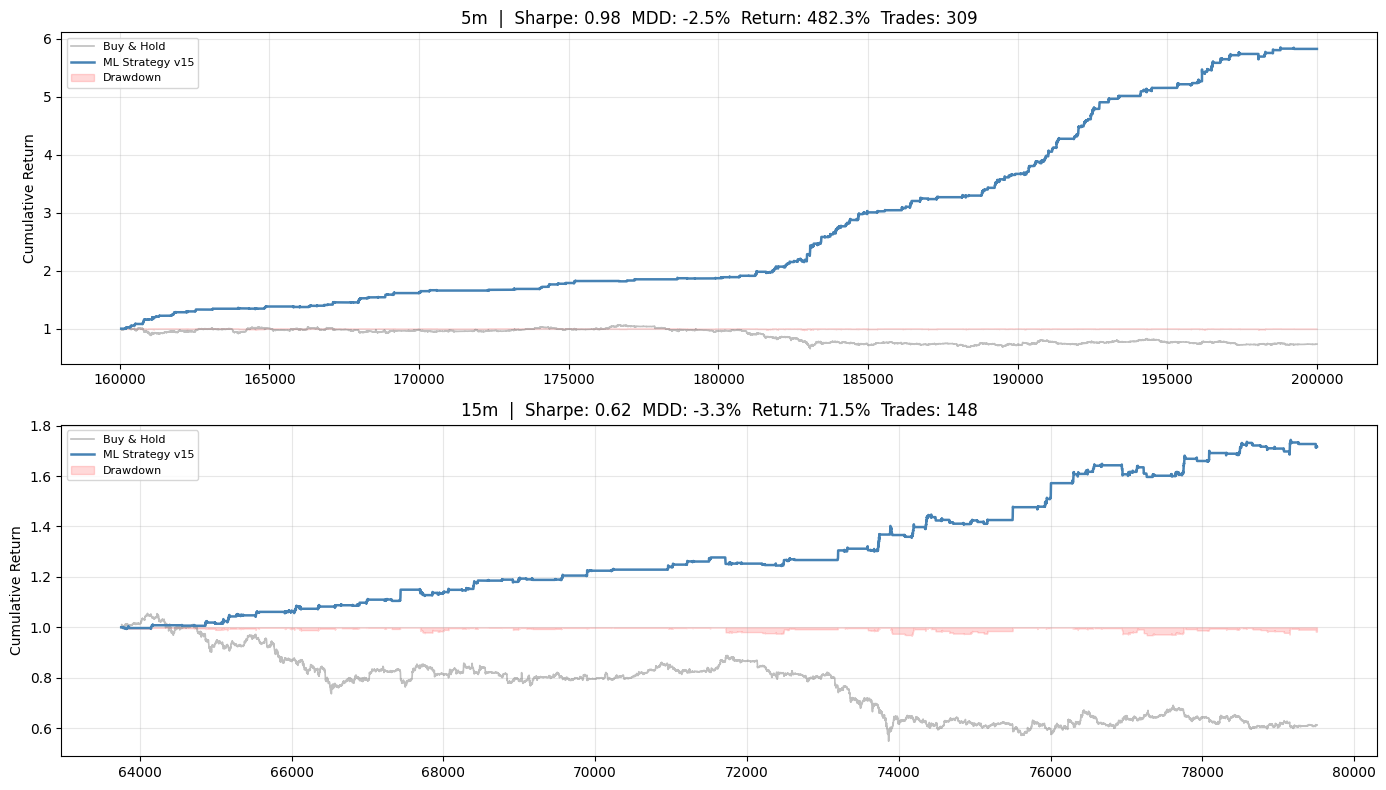

In [7]:
# Cell 6: Filtered backtest — v15
# [v14-1] Runs on holdout_splits[tf] — never seen during training
# [v14-7] Trade cost scaled by abs(position) size
# [v15-3] ATR-based trailing stop (1.5 × ATR) replaces fixed trailing_pct
# [v15-4] min_hold_bars=5 prevents premature noise exits
# [v15-5] Edge-decay exit: close long/short when edge fades below threshold
# [v15-6] Volatility filter: skip trades when market is too quiet (atr_pct low)
#
# Signal: edge = p_buy - p_sell
#   Long  when edge >  rolling_threshold AND edge >= EDGE_FLOOR
#   Short when edge < -rolling_threshold AND edge <= -EDGE_FLOOR
# Regime filter: trades only in ranging market (ADX <= 25)

COST_PER_TRADE           = TAKER_FEE + (SLIPPAGE_BPS / 10_000)
TF_FUNDING_INTERVAL_BARS = {"5m": 96, "15m": 32}
TF_BARS_PER_YEAR         = {"5m": 105_120, "15m": 35_040}


def run_backtest(df, signal, price_col="close",
                 atr_arr=None,          # [v15-3] ATR array for dynamic trailing stop
                 atr_mult=1.5,          # [v15-3] ATR multiplier (1.5× ATR default)
                 hard_sl_pct=0.01,
                 cost_pct=0.0005,
                 edge_arr=None,         # [v15-5] edge array for decay-based exit
                 edge_decay_thr=0.05,   # [v15-5] exit when |edge| drops below this
                 min_hold_bars=5):      # [v15-4] minimum bars before allowing exit

    price = df[price_col].values
    n     = len(price)

    # Fallback: fixed 0.4% trailing if no ATR provided
    _fallback_trail = 0.004

    position    = 0        # 0=flat, 1=long, -1=short
    entry_price = 0.0
    stop_price  = 0.0
    entry_idx   = None

    equity = [1.0]
    trades = []

    for i in range(1, n):
        p   = price[i]
        sig = signal.iloc[i]

        # ATR-based stop distance for this bar [v15-3]
        if atr_arr is not None and not np.isnan(atr_arr[i]) and atr_arr[i] > 0:
            trail_dist = atr_mult * atr_arr[i]
        else:
            trail_dist = p * _fallback_trail

        # Current |edge| for decay check [v15-5]
        cur_edge = abs(edge_arr[i]) if edge_arr is not None else 1.0

        prev_equity = equity[-1]
        exit_flag   = False

        # ── 1. EXIT CONDITIONS ─────────────────────────────────────────────
        if position == 1:
            # Ratchet trailing stop upward [v15-3]
            stop_price = max(stop_price, p - trail_dist)

            bars_held  = i - entry_idx
            min_hold_ok = bars_held >= min_hold_bars  # [v15-4]

            # Conditions that can close the position
            hit_trail = p <= stop_price
            hit_hard  = p <= entry_price * (1 - hard_sl_pct)
            edge_gone = cur_edge < edge_decay_thr and min_hold_ok  # [v15-5]

            if min_hold_ok and (hit_trail or hit_hard or edge_gone):
                pnl = (p - entry_price) / entry_price - cost_pct
                trades.append({
                    "type": "LONG", "entry": entry_price, "exit": p,
                    "pnl": pnl, "bars": bars_held,
                    "exit_reason": ("trail" if hit_trail else
                                    "hard_sl" if hit_hard else "edge_decay"),
                })
                position  = 0
                exit_flag = True

        elif position == -1:
            # Ratchet trailing stop downward [v15-3]
            stop_price = min(stop_price, p + trail_dist)

            bars_held   = i - entry_idx
            min_hold_ok = bars_held >= min_hold_bars  # [v15-4]

            hit_trail = p >= stop_price
            hit_hard  = p >= entry_price * (1 + hard_sl_pct)
            edge_gone = cur_edge < edge_decay_thr and min_hold_ok  # [v15-5]

            if min_hold_ok and (hit_trail or hit_hard or edge_gone):
                pnl = (entry_price - p) / entry_price - cost_pct
                trades.append({
                    "type": "SHORT", "entry": entry_price, "exit": p,
                    "pnl": pnl, "bars": bars_held,
                    "exit_reason": ("trail" if hit_trail else
                                    "hard_sl" if hit_hard else "edge_decay"),
                })
                position  = 0
                exit_flag = True

        # ── 2. ENTRY / FLIP LOGIC ─────────────────────────────────────────
        if position == 0:
            if sig == 2:    # BUY signal
                position    = 1
                entry_price = p
                stop_price  = p - trail_dist
                entry_idx   = i
            elif sig == 0:  # SELL signal
                position    = -1
                entry_price = p
                stop_price  = p + trail_dist
                entry_idx   = i
        else:
            # Allow position flip (incurs cost)
            if position == 1 and sig == 0 and (i - entry_idx) >= min_hold_bars:
                pnl = (p - entry_price) / entry_price - cost_pct
                trades.append({
                    "type": "LONG", "entry": entry_price, "exit": p,
                    "pnl": pnl, "bars": i - entry_idx, "exit_reason": "flip",
                })
                position    = -1
                entry_price = p
                stop_price  = p + trail_dist
                entry_idx   = i

            elif position == -1 and sig == 2 and (i - entry_idx) >= min_hold_bars:
                pnl = (entry_price - p) / entry_price - cost_pct
                trades.append({
                    "type": "SHORT", "entry": entry_price, "exit": p,
                    "pnl": pnl, "bars": i - entry_idx, "exit_reason": "flip",
                })
                position    = 1
                entry_price = p
                stop_price  = p - trail_dist
                entry_idx   = i

        # ── 3. EQUITY UPDATE ─────────────────────────────────────────────
        if position == 1:
            ret = (price[i] - price[i-1]) / price[i-1]
        elif position == -1:
            ret = (price[i-1] - price[i]) / price[i-1]
        else:
            ret = 0.0
        equity.append(prev_equity * (1 + ret))

    # ── 4. FORCE FINAL EXIT ───────────────────────────────────────────────
    if position != 0:
        p = price[-1]
        if position == 1:
            pnl, ttype = (p - entry_price) / entry_price - cost_pct, "LONG"
        else:
            pnl, ttype = (entry_price - p) / entry_price - cost_pct, "SHORT"
        trades.append({
            "type": ttype, "entry": entry_price, "exit": p,
            "pnl": pnl, "bars": n - entry_idx, "exit_reason": "forced",
        })

    equity = pd.Series(equity, index=df.index[:len(equity)])
    return equity, pd.DataFrame(trades)


def evaluate_performance(equity, trades):
    returns     = equity.pct_change().dropna()
    sharpe      = np.sqrt(252) * returns.mean() / (returns.std() + 1e-9)
    cum_return  = equity.iloc[-1] - 1
    drawdown    = equity / equity.cummax() - 1
    mdd         = drawdown.min()
    n_trades    = len(trades)
    win_rate    = (trades["pnl"] > 0).mean() if n_trades > 0 else 0.0
    avg_trade   = trades["pnl"].mean()        if n_trades > 0 else 0.0
    return {
        "sharpe": sharpe, "return": cum_return, "mdd": mdd,
        "trades": n_trades, "win_rate": win_rate, "avg_trade": avg_trade,
    }


def _empty_bt(tf, df):
    return {
        "timeframe": tf, "sharpe": 0.0, "max_drawdown": 0.0,
        "total_return": 0.0, "bnh_return": 0.0, "n_trades": 0,
        "win_rate": 0.0, "total_trade_cost": 0.0, "total_funding_cost": 0.0,
        "n_holdout_bars": 0, "df": df.iloc[0:0].copy(),
    }


def run_backtest_v15(df_feat, model, feature_cols, tf, train_median=None, scaler=None):

    df_bt = df_feat.copy()
    if len(df_bt) < 50:
        print(f"  {tf}: holdout too small ({len(df_bt)} bars) — skipping")
        return _empty_bt(tf, df_feat)

    train_med = train_median if train_median is not None else pd.Series(dtype=float)

    # Align features + impute with train median
    df_bt_feats = df_bt.reindex(columns=feature_cols, fill_value=np.nan)
    for col in feature_cols:
        if col in train_med.index:
            df_bt_feats[col] = df_bt_feats[col].fillna(train_med[col])
    df_bt_feats = df_bt_feats.replace([np.inf, -np.inf], 0).fillna(0)

    proba    = model.predict_proba(df_bt_feats.values)
    cls      = list(model.classes_)
    idx_sell = cls.index(0) if 0 in cls else None
    idx_buy  = cls.index(2) if 2 in cls else None
    p_sell   = proba[:, idx_sell] if idx_sell is not None else np.zeros(len(df_bt))
    p_buy    = proba[:, idx_buy]  if idx_buy  is not None else np.zeros(len(df_bt))

    # Directional edge: +ve = bullish, -ve = bearish
    edge     = p_buy - p_sell
    abs_edge = np.abs(edge)

    # Rolling percentile threshold — no look-ahead bias (falls back to global for first 200 bars)
    _rolling_thr = (
        pd.Series(abs_edge)
        .rolling(200, min_periods=20)
        .quantile(CONFIDENCE_PERCENTILE / 100.0)
        .fillna(np.percentile(abs_edge, CONFIDENCE_PERCENTILE))
        .values
    )
    threshold  = float(np.percentile(abs_edge, CONFIDENCE_PERCENTILE))
    total_cost = COST_PER_TRADE * 2

    adx_arr = (
        df_bt["adx_14"].fillna(25).values
        if "adx_14" in df_bt.columns
        else np.full(len(df_bt), 25.0)
    )
    # [v15-3] ATR for trailing stop; NaN → median fallback
    atr_col = "atr_14"
    if atr_col in df_bt.columns:
        atr_med = df_bt[atr_col].median()
        atr_arr = df_bt[atr_col].fillna(atr_med).values
    else:
        atr_arr = None

    # [v15-6] Volatility filter: atr_pct column if available
    atr_pct_arr = (
        df_bt["atr_pct"].fillna(0).values
        if "atr_pct" in df_bt.columns
        else np.full(len(df_bt), 1.0)
    )

    signal = pd.Series(1, index=df_bt.index)   # 1=hold, 0=sell, 2=buy
    last_trade_bar = -MIN_GAP_CANDLES - 1
    trades_today   = {}
    max_daily      = TF_MAX_TRADES_DAY.get(tf, 8)
    filter_counts  = {
        "edge_floor": 0, "threshold": 0, "cost": 0,
        "regime": 0, "gap": 0, "daily_cap": 0,
        "volatility": 0, "passed": 0,
    }

    for i in range(len(df_bt)):
        ae       = abs_edge[i]
        raw_edge = edge[i]
        adx_val  = adx_arr[i]
        vol_val  = atr_pct_arr[i]
        bar_date = df_bt["datetime"].iloc[i].date()

        if ae < EDGE_FLOOR:
            filter_counts["edge_floor"] += 1; continue
        if ae < _rolling_thr[i]:
            filter_counts["threshold"] += 1; continue
        if ae < total_cost * MIN_EDGE_COST_RATIO:
            filter_counts["cost"] += 1; continue
        if adx_val > 25.0:
            filter_counts["regime"] += 1; continue
        if i - last_trade_bar < MIN_GAP_CANDLES:
            filter_counts["gap"] += 1; continue
        if trades_today.get(bar_date, 0) >= max_daily:
            filter_counts["daily_cap"] += 1; continue
        # [v15-6] Skip low-volatility / dead-market conditions
        if vol_val < VOLATILITY_FILTER_PCT:
            filter_counts["volatility"] += 1; continue

        signal.iloc[i] = 2 if raw_edge > 0 else 0
        last_trade_bar = i
        trades_today[bar_date] = trades_today.get(bar_date, 0) + 1
        filter_counts["passed"] += 1

    print(f"  Filters     : {filter_counts}")
    print(f"  Edge thresh : {threshold:.4f}  floor: {EDGE_FLOOR:.4f}  "
          f"(top {100-CONFIDENCE_PERCENTILE}%)")

    df_bt["ml_signal"] = signal

    equity, trades_df = run_backtest(
        df_bt, signal, price_col="close",
        atr_arr=atr_arr, atr_mult=ATR_TRAILING_MULT,   # [v15-3]
        hard_sl_pct=0.01, cost_pct=COST_PER_TRADE,
        edge_arr=edge, edge_decay_thr=EDGE_DECAY_THRESHOLD,  # [v15-5]
        min_hold_bars=MIN_HOLD_BARS,                         # [v15-4]
    )

    df_bt["market_return"] = df_bt["close"].pct_change()
    df_bt["cum_market"]    = (1 + df_bt["market_return"]).cumprod()
    df_bt["cum_strategy"]  = equity
    df_bt["drawdown"]      = equity / equity.cummax() - 1

    perf          = evaluate_performance(equity, trades_df)
    sharpe        = perf["sharpe"]
    max_drawdown  = perf["mdd"]
    total_return  = perf["return"]
    n_trades      = perf["trades"]
    win_rate      = perf["win_rate"]
    bnh_return    = float(df_bt["cum_market"].iloc[-1] - 1)
    total_trade_cost = n_trades * COST_PER_TRADE if n_trades > 0 else 0

    # Exit reason breakdown
    if not trades_df.empty and "exit_reason" in trades_df.columns:
        print(f"  Exit reasons: {trades_df['exit_reason'].value_counts().to_dict()}")

    return {
        "timeframe":          tf,
        "sharpe":             round(sharpe, 4),
        "max_drawdown":       round(max_drawdown, 4),
        "total_return":       round(total_return, 4),
        "bnh_return":         round(bnh_return, 4),
        "n_trades":           n_trades,
        "win_rate":           round(win_rate, 4),
        "total_trade_cost":   round(total_trade_cost, 6),
        "total_funding_cost": 0.0,
        "n_holdout_bars":     len(df_bt),
        "df":                 df_bt,
        "trades":             trades_df,
    }


# ── Execute backtests ─────────────────────────────────────────────────────────
backtest_results = {}
for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    if not res or res.get("model") is None:
        print(f"\n  {tf}: no model — skipping backtest")
        continue

    print(f"\n{'='*60}\nBacktesting: {tf}")
    feature_cols  = training_results[tf]["features"]
    train_median_ = training_results[tf].get("train_median")

    bt = run_backtest_v15(
        holdout_splits[tf], res["model"], feature_cols, tf,
        train_median=train_median_
    )
    backtest_results[tf] = bt

    print(f"  Sharpe Ratio         : {bt['sharpe']:>8.4f}")
    print(f"  Max Drawdown         : {bt['max_drawdown']:>8.2%}")
    print(f"  Total Return         : {bt['total_return']:>8.2%}")
    print(f"  Buy-and-Hold Return  : {bt['bnh_return']:>8.2%}")
    print(f"  Win Rate             : {bt['win_rate']:>8.2%}")
    print(f"  Trades               : {bt['n_trades']:>8}")
    print(f"  Trade Cost (total)   : {bt['total_trade_cost']:>10.4%}")

    if "trades" in bt and not bt["trades"].empty:
        print("  Sample trades:")
        print(bt["trades"].head().to_string(index=False))

    if   bt["sharpe"] >= 1.5: print("  Sharpe >= 1.5 — institutional grade")
    elif bt["sharpe"] >= 1.0: print("  Sharpe >= 1.0 — strong; ready for paper trading")
    elif bt["sharpe"] >= 0.5: print("  Sharpe 0.5-1.0 — acceptable; monitor live")
    elif bt["sharpe"] >= 0:   print("  Sharpe 0-0.5 — marginal; tune EDGE_FLOOR or TOP_N")
    else:                     print("  Negative Sharpe — check label config or feature set")

    if res.get("dir"):
        meta_path = Path(res["dir"]) / f"metadata_BTCUSD_{tf}.json"
        if meta_path.exists():
            meta_d = json.loads(meta_path.read_text())
            meta_d["backtest"] = {k: v for k, v in bt.items() if k not in ["df", "trades"]}
            meta_path.write_text(json.dumps(meta_d, indent=2))

# ── Equity curves ─────────────────────────────────────────────────────────────
n_tf = len(TIMEFRAMES)
fig, axes = plt.subplots(n_tf, 1, figsize=(14, 4*n_tf), squeeze=False)
for ax, tf in zip(axes[:, 0], TIMEFRAMES):
    bt = backtest_results.get(tf)
    if bt is None or bt["df"].empty:
        ax.text(0.5, 0.5, f"{tf}: no data", transform=ax.transAxes, ha="center")
        continue
    df_bt = bt["df"]
    ax.plot(df_bt.index, df_bt["cum_market"],   label="Buy & Hold",      alpha=0.5, lw=1.2, color="gray")
    ax.plot(df_bt.index, df_bt["cum_strategy"], label="ML Strategy v15", lw=1.8,   color="steelblue")
    ax.fill_between(df_bt.index, df_bt["drawdown"]+1, 1, alpha=0.15, color="red", label="Drawdown")
    ax.set_title(
        f"{tf}  |  Sharpe: {bt['sharpe']:.2f}  MDD: {bt['max_drawdown']:.1%}  "
        f"Return: {bt['total_return']:.1%}  Trades: {bt['n_trades']}"
    )
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3); ax.set_ylabel("Cumulative Return")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "backtest_equity_curves_v15.png", dpi=120, bbox_inches="tight")
plt.show()


In [8]:
# Cell 7: SHAP feature importance -- v14
# [v14-1] SHAP drawn from train_splits (holdout stays unseen)
# [v14-3] Train median imputed before SHAP

for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    if not res or res.get("model") is None:
        print(f"{tf}: no model"); continue

    # [v14-1] Use TRAIN zone for SHAP — holdout stays clean
    df           = train_splits[tf]
    feature_cols = training_results[tf]["features"]
    train_med    = training_results[tf].get("train_median", pd.Series(dtype=float))
    X_df = df.reindex(columns=feature_cols, fill_value=np.nan)
    # [v14-3] Impute with train median
    if train_med is not None and len(train_med) > 0:
        X_df = X_df.fillna(train_med)
    X_s = X_df.replace([np.inf, -np.inf], 0).fillna(0).values

    sample_size = min(2000, len(X_s))  # [v13-8] increased from 500 for better SHAP coverage
    np.random.seed(RANDOM_STATE)
    X_sample = X_s[np.random.choice(len(X_s), sample_size, replace=False)]

    model = res["model"]   # XGBClassifier directly -- no unwrap needed

    try:
        explainer   = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_sample)
    except Exception as e:
        print(f"  SHAP failed for {tf}: {e}")
        continue

    if isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.mean(np.abs(sv), axis=0) for sv in shap_values], axis=0)
    else:
        abs_s = np.abs(shap_values)
        mean_abs_shap = (np.mean(np.mean(abs_s, axis=0), axis=1)
                         if abs_s.ndim == 3 else np.mean(abs_s, axis=0))

    top_idx      = np.argsort(mean_abs_shap)[-20:][::-1]
    top_features = [(feature_cols[i], mean_abs_shap[i]) for i in top_idx]
    max_imp      = max(mean_abs_shap) + 1e-12

    print(f"\n{tf} -- Top 20 Features (mean |SHAP|):")
    for feat, imp in top_features:
        bar = "#" * int(imp / max_imp * 30)
        print(f"  {feat:<38} {imp:.5f}  {bar}")

print("\nSHAP analysis complete (v14).")



5m -- Top 20 Features (mean |SHAP|):
  atr_pct                                0.33831  ##############################
  rsi_14_15m                             0.25974  #######################
  rsi_14                                 0.10210  #########
  price_vs_ema200                        0.07554  ######
  macd                                   0.06709  #####
  ema_9                                  0.06065  #####
  hl_range                               0.04544  ####
  volatility_10                          0.04099  ###
  volatility                             0.03699  ###
  adx_14                                 0.03690  ###
  macd_hist_15m                          0.03301  ##
  atr_14                                 0.03197  ##
  ema_cross_21_50                        0.03137  ##
  di_diff_15m                            0.02950  ##
  adx_14_15m                             0.02456  ##
  ema_cross_50_200_15m                   0.01816  #
  sr_near_low                            0.0

In [9]:
# Cell 8 (Adaptive): Drift Detection + Auto-Retrain Engine -- v14
# [v14-4] bfill removed from retrain window
# [v14-6] KS threshold tightened: p<0.01 AND stat>0.1
#
# [v12-6] For production deployment. Detects when feature distributions have
#         shifted (Kolmogorov-Smirnov test, p<0.05) and triggers retraining
#         on the most recent ROLLING_DAYS of data.
#
# NOTE: Run AFTER the main training + backtest pipeline.
#       Do NOT run during backtesting -- that would be look-ahead leakage.

ROLLING_DAYS         = 60    # days of recent data used for adaptive retrain
DRIFT_FEATURE_LIMIT  = 5     # retrain if more than N features drift
DRIFT_ALPHA          = 0.01  # [v14-6] tightened from 0.05 to reduce false alarms
DRIFT_STAT_THRESHOLD = 0.10  # [v14-6] minimum KS statistic (effect size)


def detect_drift(df_past, df_recent, feature_cols):
    """Return list of features whose distribution changed (KS test p < DRIFT_ALPHA)."""
    drifted = []
    for col in feature_cols:
        if col not in df_past.columns or col not in df_recent.columns:
            continue
        past_vals   = df_past[col].dropna().values
        recent_vals = df_recent[col].dropna().values
        if len(past_vals) < 30 or len(recent_vals) < 30:
            continue
        stat, p = ks_2samp(past_vals, recent_vals)
        # [v14-6] Require both statistical significance AND meaningful effect size
        if p < DRIFT_ALPHA and stat > DRIFT_STAT_THRESHOLD:
            drifted.append((col, round(p, 4)))
    return drifted


def get_recent_data(df, days=ROLLING_DAYS):
    """Slice to the most recent `days` calendar days."""
    cutoff = df["datetime"].max() - pd.Timedelta(days=days)
    return df[df["datetime"] >= cutoff].copy()


def adaptive_engine(tf, labeled_data, training_results, feature_history):
    """
    Compare recent vs past distributions; retrain if drift exceeds threshold.
    Returns (updated_model, updated_scaler, updated_features) or None if skipped.
    """
    res = training_results.get(tf, {})
    if not res or res.get("model") is None:
        print(f"[Adaptive:{tf}] No base model -- skip")
        return None

    df           = labeled_data.get(tf, pd.DataFrame())
    feature_cols = res["features"]

    if df.empty or len(df) < 40000:
        print(f"[Adaptive:{tf}] Insufficient data ({len(df):,} rows) -- skip")
        return None

    # split into past and recent
    df_recent = df.iloc[-20000:]
    df_past   = df.iloc[-40000:-20000]

    # drift detection
    drifted = detect_drift(df_past, df_recent, feature_cols)
    print(f"[Adaptive:{tf}] Drifted features ({len(drifted)}): "
          f"{[d[0] for d in drifted[:5]]}{'...' if len(drifted)>5 else ''}")

    if len(drifted) <= DRIFT_FEATURE_LIMIT:
        print(f"[Adaptive:{tf}] Drift ({len(drifted)}) <= limit ({DRIFT_FEATURE_LIMIT}) -- no retrain")
        return None

    print(f"[Adaptive:{tf}] Drift threshold exceeded -- RETRAINING on recent data")

    # slice recent window for retraining
    df_train = get_recent_data(df, days=ROLLING_DAYS)
    # [v13-1] ffill/bfill to avoid silent row collapse
    df_clean = df_train[feature_cols + ["label"]].copy()
    # [v14-4] ffill only — no bfill to avoid future leakage
    df_clean[feature_cols] = (df_clean[feature_cols]
                               .replace([np.inf, -np.inf], np.nan)
                               .ffill(limit=5))
    df_clean = df_clean.dropna(subset=["label"])

    if len(df_clean) < 1000:
        print(f"[Adaptive:{tf}] Recent window too small ({len(df_clean)}) -- skip")
        return None

    X_vals = df_clean[feature_cols].values
    y_vals = df_clean["label"].values

    # [v13-3] No scaler for XGBoost
    X_s = X_vals
    sw  = compute_sample_weight("balanced", y_vals)

    new_model = build_xgb()
    new_model.fit(X_s, y_vals, sample_weight=sw)

    f1 = f1_score(y_vals, new_model.predict(X_s), average="macro", zero_division=0)
    print(f"[Adaptive:{tf}] Retrain F1 (train): {f1:.4f}  Samples: {len(y_vals):,}")

    # record history
    feature_history.append({
        "tf": tf, "time": pd.Timestamp.utcnow().isoformat(),
        "drifted": len(drifted), "features": feature_cols,
        "f1_train": round(f1, 4), "n_samples": len(y_vals),
    })

    print(f"[Adaptive:{tf}] Retrain complete. Update training_results to deploy.")
    return new_model, feature_cols   # [v14] no scaler


# ── Run Adaptive Engine ───────────────────────────────────────────────────────
feature_history = []

print("=" * 60)
print("ADAPTIVE ENGINE v14")
print("=" * 60)

adaptive_updates = {}
for tf in TIMEFRAMES:
    result = adaptive_engine(tf, labeled_data, training_results, feature_history)
    if result is not None:
        new_model, new_features = result   # [v14] no scaler
        adaptive_updates[tf] = {
            "model":    new_model,
            "scaler":   None,       # [v13-3] no scaler for XGBoost
            "features": new_features,
        }
        print(f"  [{tf}] Adaptive model ready. To deploy, run:\n"
              f"       training_results['{tf}']['model']    = adaptive_updates['{tf}']['model']\n"
              f"       training_results['{tf}']['features'] = adaptive_updates['{tf}']['features']")
    else:
        print(f"  [{tf}] No adaptive update triggered.")

print(f"\nDrift history entries: {len(feature_history)}")
if feature_history:
    for entry in feature_history:
        print(f"  {entry['tf']} @ {entry['time']}: "
              f"{entry['drifted']} features drifted, F1={entry['f1_train']:.4f}")


ADAPTIVE ENGINE v14
[Adaptive:5m] Drifted features (7): ['atr_14', 'atr_pct', 'ema_9', 'price_vs_ema200', 'sr_near_low']...
[Adaptive:5m] Drift threshold exceeded -- RETRAINING on recent data
[Adaptive:5m] Retrain F1 (train): 0.7445  Samples: 17,281
[Adaptive:5m] Retrain complete. Update training_results to deploy.
  [5m] Adaptive model ready. To deploy, run:
       training_results['5m']['model']    = adaptive_updates['5m']['model']
       training_results['5m']['features'] = adaptive_updates['5m']['features']
[Adaptive:15m] Drifted features (4): ['ema_9', 'price_vs_ema200', 'volatility', 'volatility_10']
[Adaptive:15m] Drift (4) <= limit (5) -- no retrain
  [15m] No adaptive update triggered.

Drift history entries: 1
  5m @ 2026-04-05T19:08:35.386594+00:00: 7 features drifted, F1=0.7445


In [10]:
# Cell 9: Final validation summary — v15
print("\n" + "=" * 60)
print("FINAL VALIDATION SUMMARY  (JackSparrow v15)")
print("=" * 60)
print("Signal : edge = p_buy - p_sell | XGBoost | balanced weights | no SMOTE")
print("Exits  : ATR trailing | hard SL | edge decay | min hold")
print("=" * 60)

all_pass = True

for tf in TIMEFRAMES:
    res = training_results.get(tf, {})
    bt  = backtest_results.get(tf, {})

    if not res or res.get("model") is None:
        print(f"\n  {tf}: NO MODEL TRAINED")
        print(f"    >> Check Cell 2.5 — if coverage < 90%, fix Cell 2 fetch.")
        all_pass = False
        continue

    n_train   = len(train_splits.get(tf, pd.DataFrame()))
    n_holdout = len(holdout_splits.get(tf, pd.DataFrame()))
    mean_f1   = res.get("mean_f1", 0)
    sharpe    = bt.get("sharpe")
    mdd       = bt.get("max_drawdown")
    ret       = bt.get("total_return")
    n_trades  = bt.get("n_trades")
    win_rate  = bt.get("win_rate")
    n_feat    = len(res.get("features", []))

    print(f"\n  {tf}:")
    print(f"    model_version        : v15 (strict train/holdout split, no leakage)")
    print(f"    features selected    : {n_feat}")
    print(f"    training rows        : {n_train:,}  (holdout: {n_holdout:,} rows)")
    print(f"    cv_f1_macro (honest) : {mean_f1:.4f}  [TimeSeriesSplit, no leakage]")
    print(f"    backtest.sharpe      : {sharpe}")
    print(f"    backtest.mdd         : {mdd:.2%}"       if mdd      is not None else "    backtest.mdd : N/A")
    print(f"    backtest.return      : {ret:.2%}"        if ret      is not None else "    backtest.return : N/A")
    print(f"    backtest.trades      : {n_trades}")
    print(f"    backtest.win_rate    : {win_rate:.2%}"  if win_rate is not None else "    backtest.win_rate : N/A")

    if sharpe is None:
        print("    WARN: No backtest result")
    elif sharpe >= 1.5:
        print("    PASS: Sharpe >= 1.5 — institutional grade")
    elif sharpe >= 1.0:
        print("    PASS: Sharpe >= 1.0 — strong; ready for paper trading")
    elif sharpe >= 0.5:
        print("    PASS: Sharpe 0.5-1.0 — acceptable; monitor live")
    elif sharpe >= 0:
        print("    MARGINAL: Sharpe 0-0.5 — tune EDGE_FLOOR or TOP_N_FEATURES")
        all_pass = False
    else:
        print("    FAIL: Negative Sharpe — review label config or feature set")
        all_pass = False

    if n_train < 10_000:
        print(f"    WARN: Low training rows ({n_train:,})")
        all_pass = False

print(f"\n{'=' * 60}")
if all_pass:
    print("ALL TIMEFRAMES VALIDATED — ready for paper trading")
    print(f"   Output: {OUTPUT_DIR}")
else:
    print("REVIEW REQUIRED — address warnings above before going live")

print(f"\nActive timeframes : {TIMEFRAMES}")
print("Reminder: Paper-trade for >= 1 week before live capital")
print("Reminder: 5x isolated margin on Delta Exchange India")
print("Reminder: Enable 2FA before activating bot")
print("\nQuick-tune knobs (Cell 1):")
print("  EDGE_FLOOR            (default 0.15) — raise to reduce trades, improve quality")
print("  CONFIDENCE_PERCENTILE (default 90)   — raise for even stronger signal filter")
print("  TOP_N_FEATURES        (default 20)   — lower to reduce noise")
print("  ATR_TRAILING_MULT     (default 1.5)  — raise for wider stop, lower for tighter")
print("  MIN_HOLD_BARS         (default 5)    — raise to prevent more premature exits")
print("  EDGE_DECAY_THRESHOLD  (default 0.05) — raise to exit sooner on fading edge")
print("  VOLATILITY_FILTER_PCT (default 0.002)— raise to trade only in active markets")
print("  TP_LONG_PCT / SL_LONG_PCT            — adjust risk/reward per timeframe")



FINAL VALIDATION SUMMARY  (JackSparrow v15)
Signal : edge = p_buy - p_sell | XGBoost | balanced weights | no SMOTE
Exits  : ATR trailing | hard SL | edge decay | min hold

  5m:
    model_version        : v15 (strict train/holdout split, no leakage)
    features selected    : 20
    training rows        : 159,784  (holdout: 39,950 rows)
    cv_f1_macro (honest) : 0.4473  [TimeSeriesSplit, no leakage]
    backtest.sharpe      : 0.9751
    backtest.mdd         : -2.52%
    backtest.return      : 482.27%
    backtest.trades      : 309
    backtest.win_rate    : 64.08%
    PASS: Sharpe 0.5-1.0 — acceptable; monitor live

  15m:
    model_version        : v15 (strict train/holdout split, no leakage)
    features selected    : 20
    training rows        : 63,005  (holdout: 15,756 rows)
    cv_f1_macro (honest) : 0.3200  [TimeSeriesSplit, no leakage]
    backtest.sharpe      : 0.6229
    backtest.mdd         : -3.32%
    backtest.return      : 71.48%
    backtest.trades      : 148
    backt

In [11]:
# Cell 10: Download model artifacts — v15
import shutil, tempfile
from pathlib import Path

temp_dir  = tempfile.mkdtemp()
temp_path = Path(temp_dir)

print(f"Selective download: v15 models for {TIMEFRAMES}")

copied_items = []
for tf in TIMEFRAMES:
    src_dir = OUTPUT_DIR / f"model_{tf}_v14"   # training still saves under v14 dir
    if src_dir.exists():
        dst_dir = temp_path / f"model_{tf}_v14"
        shutil.copytree(src_dir, dst_dir)
        copied_items.append(f"model_{tf}_v14")
        print(f"  ✓ Copied: {src_dir.name}")
    else:
        print(f"  ⚠️  Missing: {src_dir.name}")

for plot_name in ["backtest_equity_curves_v15.png", "backtest_equity_curves_v14.png"]:
    plot_src = OUTPUT_DIR / plot_name
    if plot_src.exists():
        shutil.copy2(plot_src, temp_path / plot_name)
        copied_items.append(plot_name)
        print(f"  ✓ Copied: {plot_name}")
        break

if not copied_items:
    print("  ❌ No models found to download!")
else:
    print(f"  📦 Items: {copied_items}")
    zip_base = "/content/JackSparrow_Models_v15"
    zip_path = zip_base + ".zip"
    shutil.make_archive(zip_base, "zip", root_dir=temp_dir, base_dir=".")
    print(f"Archive: {zip_path}")
    try:
        from google.colab import files
        files.download(zip_path)
        print("Download triggered.")
    except ImportError:
        print(f"Not in Colab. Archive at: {zip_path}")

shutil.rmtree(temp_dir)
print("Temp directory cleaned up.")


Selective download: v15 models for ['5m', '15m']
  ✓ Copied: model_5m_v14
  ✓ Copied: model_15m_v14
  ✓ Copied: backtest_equity_curves_v15.png
  📦 Items: ['model_5m_v14', 'model_15m_v14', 'backtest_equity_curves_v15.png']
Archive: /content/JackSparrow_Models_v15.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered.
Temp directory cleaned up.
